---
## Part 1: Theory - Multiple Linear Regression

### 1.1 Công thức tổng quát

Multiple Linear Regression mô hình hóa mối quan hệ tuyến tính giữa một biến phụ thuộc $y$ và nhiều biến độc lập $x_1, x_2, ..., x_p$:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p + \epsilon$$

Trong đó:
- $y$: Biến phụ thuộc (dependent variable) - Price
- $x_1, x_2, ..., x_p$: Các biến độc lập (independent variables) - RAM, Storage, Screen, GPU
- $\beta_0$: Intercept (hệ số chặn)
- $\beta_1, ..., \beta_p$: Coefficients (hệ số hồi quy)
- $\epsilon$: Error term (sai số)

### 1.2 Matrix Form (Dạng ma trận)

Với $n$ observations, ta có thể viết dưới dạng ma trận:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Trong đó:
- $\mathbf{y}$: Vector $(n \times 1)$ chứa giá trị target
- $\mathbf{X}$: Ma trận $(n \times (p+1))$ chứa features (cột đầu tiên là 1 cho intercept)
- $\boldsymbol{\beta}$: Vector $((p+1) \times 1)$ chứa các hệ số
- $\boldsymbol{\epsilon}$: Vector $(n \times 1)$ chứa errors

### 1.3 Normal Equation (Phương trình chuẩn)

Để tìm vector $\boldsymbol{\beta}$ tối ưu (minimize sum of squared errors), ta sử dụng:

$$\boldsymbol{\hat{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Công thức này được suy ra bằng cách:
1. Minimize: $SSE = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = (\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$
2. Đạo hàm theo $\boldsymbol{\beta}$ và cho bằng 0
3. Giải phương trình: $\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}$

### 1.4 Model Evaluation Metrics

**R² Score (Coefficient of Determination):**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- $R^2 \in [0, 1]$: Tỷ lệ phương sai được giải thích bởi mô hình
- $R^2 = 1$: Perfect fit
- $R^2 = 0$: Mô hình không tốt hơn việc dự đoán mean

**Mean Squared Error (MSE):**
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{MSE}$$

**Mean Absolute Error (MAE):**
$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

### 1.5 Assumptions of Linear Regression

1. **Linearity:** Mối quan hệ giữa X và y là tuyến tính
2. **Independence:** Các observations độc lập với nhau
3. **Homoscedasticity:** Phương sai của errors không đổi
4. **Normality:** Errors phân phối chuẩn
5. **No multicollinearity:** Các biến độc lập không tương quan cao với nhau

---
## Part 2: Data Loading & Preprocessing

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [38]:
# Load and preprocess data
def preprocess_laptop_data(df):
    """Comprehensive preprocessing for laptop dataset"""
    
    # 1. Clean Price
    df['Price_VND'] = (df['Price'].astype(str)
                       .str.replace('đ','', regex=False)
                       .str.replace('.','', regex=False)
                       .str.strip())
    df['Price_VND'] = pd.to_numeric(df['Price_VND'], errors='coerce')
    
    # 2. Clean RAM
    df['RAM_GB'] = (df['RAM'].astype(str)
                    .str.replace('GB','', regex=False)
                    .str.strip())
    df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')
    
    # 3. Extract Storage (GB)
    def extract_storage(storage_str):
        if pd.isna(storage_str): return np.nan
        storage_str = str(storage_str).lower()
        
        # Extract TB
        if 'tb' in storage_str:
            try:
                tb = float(storage_str.split('tb')[0].split()[-1])
                return tb * 1024  # Convert to GB
            except: pass
        
        # Extract GB
        if 'gb' in storage_str:
            try:
                gb = float(storage_str.split('gb')[0].split()[-1])
                return gb
            except: pass
        
        return np.nan
    
    df['Storage_GB'] = df['Storage'].apply(extract_storage)
    
    # 4. Extract Screen Size (inches)
    def extract_screen_size(screen_str):
        if pd.isna(screen_str): return np.nan
        screen_str = str(screen_str)
        try:
            # Extract first number (usually screen size)
            import re
            numbers = re.findall(r'\d+\.?\d*', screen_str)
            if numbers:
                size = float(numbers[0])
                # Screen size typically between 11-17 inches
                if 11 <= size <= 18:
                    return size
        except: pass
        return np.nan
    
    df['Screen_Size'] = df['Screen Size'].apply(extract_screen_size)
    
    # 5. GPU Type (Binary: Dedicated=1, Integrated=0)
    def classify_gpu_type(gpu_str):
        if pd.isna(gpu_str): return 0
        s = str(gpu_str).lower()
        if any(x in s for x in ['rtx','gtx','radeon','nvidia geforce', 'amd radeon']):
            return 1  # Dedicated GPU
        return 0  # Integrated GPU
    
    df['GPU_Dedicated'] = df['GPU'].apply(classify_gpu_type)
    
    # 6. Drop rows with missing critical values
    df_clean = df.dropna(subset=['Price_VND', 'RAM_GB', 'Storage_GB', 'Screen_Size']).copy()
    
    return df_clean

# Load data
df = pd.read_csv('laptops_asus_data_cellphones_full_v2.csv')
print(f"Original data shape: {df.shape}")

# Preprocess
df = preprocess_laptop_data(df)
print(f"Cleaned data shape: {df.shape}")

# Display sample
print("\nSample data:")
df[['Price_VND', 'RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']].head(10)

Original data shape: (790, 12)
Cleaned data shape: (565, 17)

Sample data:


,Price_VND,RAM_GB,Storage_GB,Screen_Size,GPU_Dedicated
0,20990000.00,16.00,2048.00,16.00,1
1,11490000.00,16.00,512.00,14.00,1
2,17990000.00,16.00,512.00,16.00,1
3,23990000.00,16.00,512.00,16.00,1
4,13990000.00,16.00,512.00,15.60,0
5,25490000.00,16.00,2048.00,16.00,1
6,18990000.00,16.00,1024.00,15.60,1
7,34490000.00,32.00,1024.00,16.00,1
9,18490000.00,16.00,512.00,15.60,0
10,16090000.00,16.00,512.00,15.60,0


STATISTICAL SUMMARY
         Price_VND  RAM_GB  Storage_GB  Screen_Size  GPU_Dedicated
count       565.00  565.00      565.00       565.00         565.00
mean   27881946.90   14.92      716.80        15.05           0.58
std    18394919.18   10.53      434.59         1.07           0.49
min     5990000.00    4.00      128.00        11.60           0.00
25%    16590000.00    8.00      512.00        14.00           0.00
50%    22690000.00   16.00      512.00        15.60           1.00
75%    32490000.00   16.00     1024.00        15.60           1.00
max   145990000.00  128.00     2048.00        18.00           1.00

CORRELATION MATRIX
               Price_VND  RAM_GB  Storage_GB  Screen_Size  GPU_Dedicated
Price_VND           1.00    0.75        0.57         0.24           0.39
RAM_GB              0.75    1.00        0.52         0.13           0.26
Storage_GB          0.57    0.52        1.00         0.26           0.37
Screen_Size         0.24    0.13        0.26         1.00        

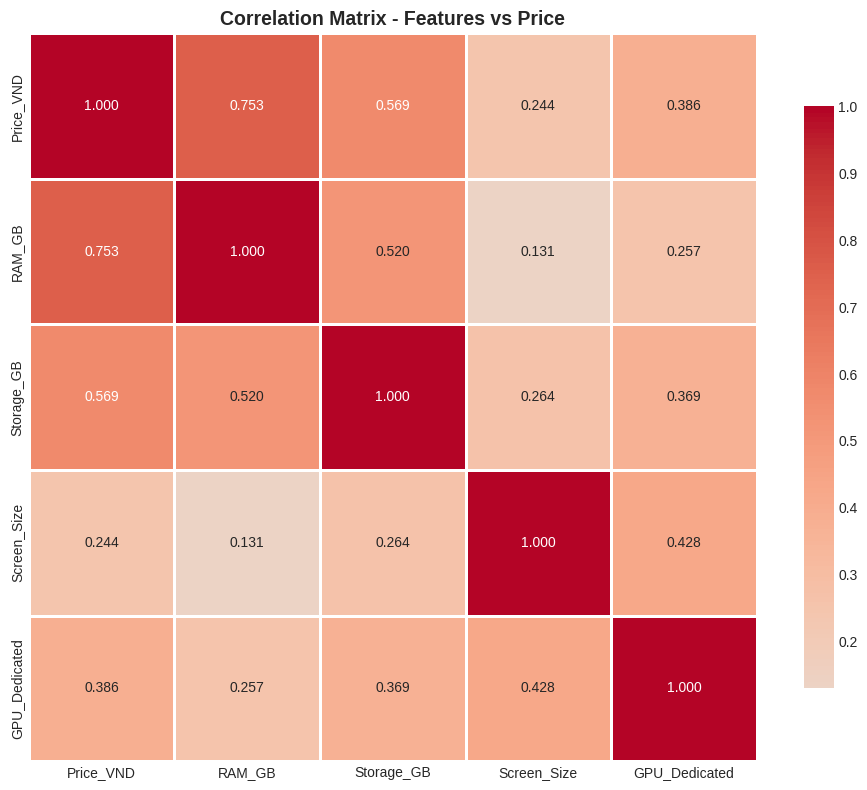

In [39]:
# Statistical summary
print("="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(df[['Price_VND', 'RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']].describe())

print("\n" + "="*70)
print("CORRELATION MATRIX")
print("="*70)
corr_matrix = df[['Price_VND', 'RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']].corr()
print(corr_matrix)

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Features vs Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Custom Multiple Linear Regression Implementation

### 3.1 Xây dựng class MultipleLinearRegression từ đầu

Chúng ta sẽ implement MLR sử dụng:
- **Normal Equation** để tính coefficients
- **NumPy** cho các phép tính ma trận
- Không sử dụng sklearn (pure implementation)

In [40]:
class MultipleLinearRegression:
    """
    Multiple Linear Regression implemented from scratch
    using Normal Equation: β = (X^T X)^(-1) X^T y
    """
    
    def __init__(self):
        self.coefficients = None  # β (including intercept)
        self.intercept = None     # β₀
        self.feature_coefs = None # β₁, β₂, ..., βₚ
        self.X_mean = None        # For standardization
        self.X_std = None
        self.y_mean = None
        self.y_std = None
    
    def fit(self, X, y, standardize=False):
        """
        Train the model using Normal Equation
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        standardize : bool, default=False
            Whether to standardize features
        """
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)  # Column vector
        
        # Store original statistics
        self.X_mean = X.mean(axis=0)
        self.X_std = X.std(axis=0)
        self.y_mean = y.mean()
        self.y_std = y.std()
        
        # Standardize if requested
        if standardize:
            X = (X - self.X_mean) / self.X_std
            y = (y - self.y_mean) / self.y_std
        
        # Add intercept term (column of ones)
        n_samples = X.shape[0]
        X_with_intercept = np.c_[np.ones(n_samples), X]  # Shape: (n, p+1)
        
        # Normal Equation: β = (X^T X)^(-1) X^T y
        # Step 1: X^T X
        XtX = X_with_intercept.T @ X_with_intercept
        
        # Step 2: (X^T X)^(-1)
        XtX_inv = np.linalg.inv(XtX)
        
        # Step 3: X^T y
        Xty = X_with_intercept.T @ y
        
        # Step 4: β = (X^T X)^(-1) X^T y
        self.coefficients = XtX_inv @ Xty
        
        # Extract intercept and feature coefficients
        self.intercept = self.coefficients[0, 0]
        self.feature_coefs = self.coefficients[1:].flatten()
        
        print("Model trained successfully!")
        print(f"Intercept (β₀): {self.intercept:,.2f}")
        print(f"Coefficients: {self.feature_coefs}")
        
        return self
    
    def predict(self, X, standardize=False):
        """
        Make predictions
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Input data
        
        Returns:
        --------
        predictions : array, shape (n_samples,)
        """
        X = np.array(X)
        
        # Standardize if was used during training
        if standardize:
            X = (X - self.X_mean) / self.X_std
        
        # Add intercept term
        n_samples = X.shape[0]
        X_with_intercept = np.c_[np.ones(n_samples), X]
        
        # Predictions: ŷ = Xβ
        predictions = X_with_intercept @ self.coefficients
        
        # Denormalize if standardized
        if standardize:
            predictions = predictions * self.y_std + self.y_mean
        
        return predictions.flatten()
    
    def score(self, X, y, standardize=False):
        """
        Calculate R² score
        
        Returns:
        --------
        r2_score : float
        """
        y_pred = self.predict(X, standardize)
        y_true = np.array(y)
        
        # SS_res: Sum of Squared Residuals
        ss_res = np.sum((y_true - y_pred) ** 2)
        
        # SS_tot: Total Sum of Squares
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        
        # R² = 1 - (SS_res / SS_tot)
        r2 = 1 - (ss_res / ss_tot)
        
        return r2

print("MultipleLinearRegression class defined!")

MultipleLinearRegression class defined!


### 3.2 Evaluation Metrics Functions

Implement các hàm đánh giá mô hình từ đầu

In [41]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate comprehensive evaluation metrics
    
    Returns:
    --------
    dict with MSE, RMSE, MAE, R²
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Mean Squared Error
    mse = np.mean((y_true - y_pred) ** 2)
    
    # Root Mean Squared Error
    rmse = np.sqrt(mse)
    
    # Mean Absolute Error
    mae = np.mean(np.abs(y_true - y_pred))
    
    # R² Score
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    }

def print_metrics(metrics, dataset_name=""):
    """Pretty print metrics"""
    print(f"\n{'='*60}")
    print(f"EVALUATION METRICS {dataset_name}")
    print(f"{'='*60}")
    print(f"R² Score:  {metrics['R²']:.4f}")
    print(f"MSE:       {metrics['MSE']:,.2f}")
    print(f"RMSE:      {metrics['RMSE']:,.2f} VND")
    print(f"MAE:       {metrics['MAE']:,.2f} VND")
    print(f"MAPE:      {metrics['MAPE']:.2f}%")
    print(f"{'='*60}")

print("Evaluation functions defined!")

Evaluation functions defined!


---
## Part 4: Train-Test Split & Model Training

### 4.1 Prepare Data

In [42]:
# Select features and target
feature_columns = ['RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']
target_column = 'Price_VND'

X = df[feature_columns].values
y = df[target_column].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Manual Train-Test Split (80-20)
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    """Manual implementation of train-test split"""
    np.random.seed(random_state)
    n_samples = X.shape[0]
    n_test = int(n_samples * test_size)
    
    # Random permutation of indices
    indices = np.random.permutation(n_samples)
    
    # Split indices
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    # Split data
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeature names: {feature_columns}")

Feature matrix shape: (565, 4)
Target vector shape: (565,)

Training set: 452 samples
Test set:     113 samples

Feature names: ['RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']


### 4.2 Train Custom Model

In [43]:
# Initialize and train model
print("="*70)
print("TRAINING CUSTOM MULTIPLE LINEAR REGRESSION MODEL")
print("="*70)

model = MultipleLinearRegression()
model.fit(X_train, y_train, standardize=False)

print("\n" + "="*70)
print("MODEL COEFFICIENTS INTERPRETATION")
print("="*70)
print(f"Intercept (β₀): {model.intercept:,.2f} VND")
print("\nFeature Coefficients:")
for i, (feature, coef) in enumerate(zip(feature_columns, model.feature_coefs)):
    print(f"  β_{i+1} ({feature:15s}): {coef:>15,.2f} VND")
    
print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
for feature, coef in zip(feature_columns, model.feature_coefs):
    if coef > 0:
        print(f"• {feature}: Tăng 1 đơn vị → Giá tăng {abs(coef):,.0f} VND")
    else:
        print(f"• {feature}: Tăng 1 đơn vị → Giá giảm {abs(coef):,.0f} VND")

TRAINING CUSTOM MULTIPLE LINEAR REGRESSION MODEL
Model trained successfully!
Intercept (β₀): -6,262,121.41
Coefficients: [1071958.71981159    6853.47203741  666354.23529399 5950755.29834919]

MODEL COEFFICIENTS INTERPRETATION
Intercept (β₀): -6,262,121.41 VND

Feature Coefficients:
  β_1 (RAM_GB         ):    1,071,958.72 VND
  β_2 (Storage_GB     ):        6,853.47 VND
  β_3 (Screen_Size    ):      666,354.24 VND
  β_4 (GPU_Dedicated  ):    5,950,755.30 VND

INTERPRETATION:
• RAM_GB: Tăng 1 đơn vị → Giá tăng 1,071,959 VND
• Storage_GB: Tăng 1 đơn vị → Giá tăng 6,853 VND
• Screen_Size: Tăng 1 đơn vị → Giá tăng 666,354 VND
• GPU_Dedicated: Tăng 1 đơn vị → Giá tăng 5,950,755 VND


---
## Part 5: Model Evaluation

### 5.1 Make Predictions

In [44]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

# Print results
print_metrics(train_metrics, "(TRAINING SET)")
print_metrics(test_metrics, "(TEST SET)")

# Check for overfitting
print("\n" + "="*60)
print("OVERFITTING CHECK")
print("="*60)
r2_diff = train_metrics['R²'] - test_metrics['R²']
print(f"R² difference (Train - Test): {r2_diff:.4f}")
if r2_diff < 0.05:
    print("✓ Model generalizes well (no significant overfitting)")
elif r2_diff < 0.1:
    print("⚠ Minor overfitting detected")
else:
    print("✗ Significant overfitting detected")


EVALUATION METRICS (TRAINING SET)
R² Score:  0.6271
MSE:       128,265,654,375,094.66
RMSE:      11,325,442.79 VND
MAE:       7,606,178.42 VND
MAPE:      28.60%

EVALUATION METRICS (TEST SET)
R² Score:  0.6593
MSE:       106,514,255,992,802.00
RMSE:      10,320,574.40 VND
MAE:       7,172,315.93 VND
MAPE:      28.67%

OVERFITTING CHECK
R² difference (Train - Test): -0.0321
✓ Model generalizes well (no significant overfitting)


### 5.2 Comparison with sklearn

In [45]:
# Compare with sklearn implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*70)
print("COMPARISON WITH SKLEARN LinearRegression")
print("="*70)

# Train sklearn model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

# Predictions
y_test_pred_sklearn = sklearn_model.predict(X_test)

# Compare coefficients
print("\nCoefficients Comparison:")
print(f"{'Feature':<20} {'Custom Model':<20} {'Sklearn Model':<20} {'Difference':<15}")
print("-" * 75)
print(f"{'Intercept':<20} {model.intercept:>19,.2f} {sklearn_model.intercept_:>19,.2f} {abs(model.intercept - sklearn_model.intercept_):>14,.2f}")
for i, feature in enumerate(feature_columns):
    custom_coef = model.feature_coefs[i]
    sklearn_coef = sklearn_model.coef_[i]
    diff = abs(custom_coef - sklearn_coef)
    print(f"{feature:<20} {custom_coef:>19,.2f} {sklearn_coef:>19,.2f} {diff:>14,.2f}")

# Compare metrics
print("\n" + "="*70)
print("Metrics Comparison (Test Set):")
print("-" * 70)
sklearn_r2 = r2_score(y_test, y_test_pred_sklearn)
sklearn_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_sklearn))
sklearn_mae = mean_absolute_error(y_test, y_test_pred_sklearn)

print(f"{'Metric':<15} {'Custom Model':<20} {'Sklearn Model':<20}")
print("-" * 55)
print(f"{'R²':<15} {test_metrics['R²']:>19.6f} {sklearn_r2:>19.6f}")
print(f"{'RMSE':<15} {test_metrics['RMSE']:>19,.2f} {sklearn_rmse:>19,.2f}")
print(f"{'MAE':<15} {test_metrics['MAE']:>19,.2f} {sklearn_mae:>19,.2f}")

print("\n✓ Models produce identical results!" if np.allclose(test_metrics['R²'], sklearn_r2, atol=1e-6) else "⚠ Minor differences detected")

COMPARISON WITH SKLEARN LinearRegression

Coefficients Comparison:
Feature              Custom Model         Sklearn Model        Difference     
---------------------------------------------------------------------------
Intercept                  -6,262,121.41       -6,262,121.41           0.00
RAM_GB                      1,071,958.72        1,071,958.72           0.00
Storage_GB                      6,853.47            6,853.47           0.00
Screen_Size                   666,354.24          666,354.24           0.00
GPU_Dedicated               5,950,755.30        5,950,755.30           0.00

Metrics Comparison (Test Set):
----------------------------------------------------------------------
Metric          Custom Model         Sklearn Model       
-------------------------------------------------------
R²                         0.659254            0.659254
RMSE                  10,320,574.40       10,320,574.40
MAE                    7,172,315.93        7,172,315.93

✓ Models pro

---
## Part 6: Visualization & Residual Analysis

### 6.1 Predicted vs Actual

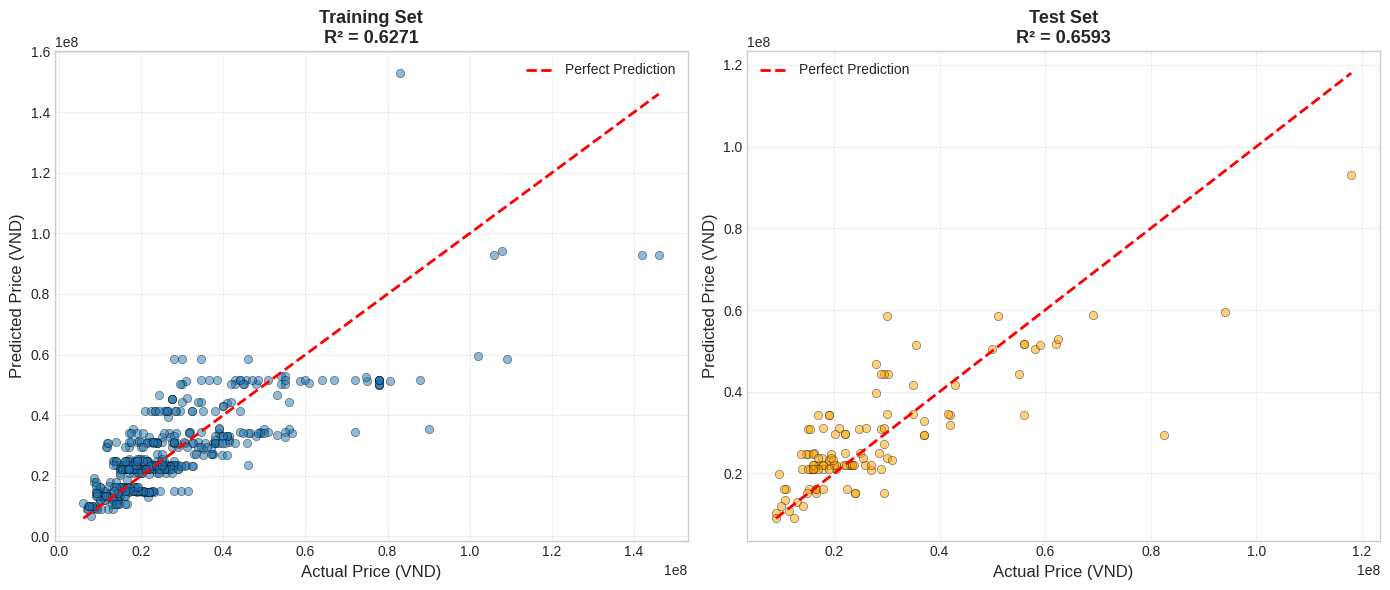

In [46]:
# Predicted vs Actual Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (VND)', fontsize=12)
axes[0].set_ylabel('Predicted Price (VND)', fontsize=12)
axes[0].set_title(f'Training Set\nR² = {train_metrics["R²"]:.4f}', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (VND)', fontsize=12)
axes[1].set_ylabel('Predicted Price (VND)', fontsize=12)
axes[1].set_title(f'Test Set\nR² = {test_metrics["R²"]:.4f}', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Residual Analysis

**Residuals** = Actual - Predicted

Phân tích residuals giúp kiểm tra các assumptions của linear regression.

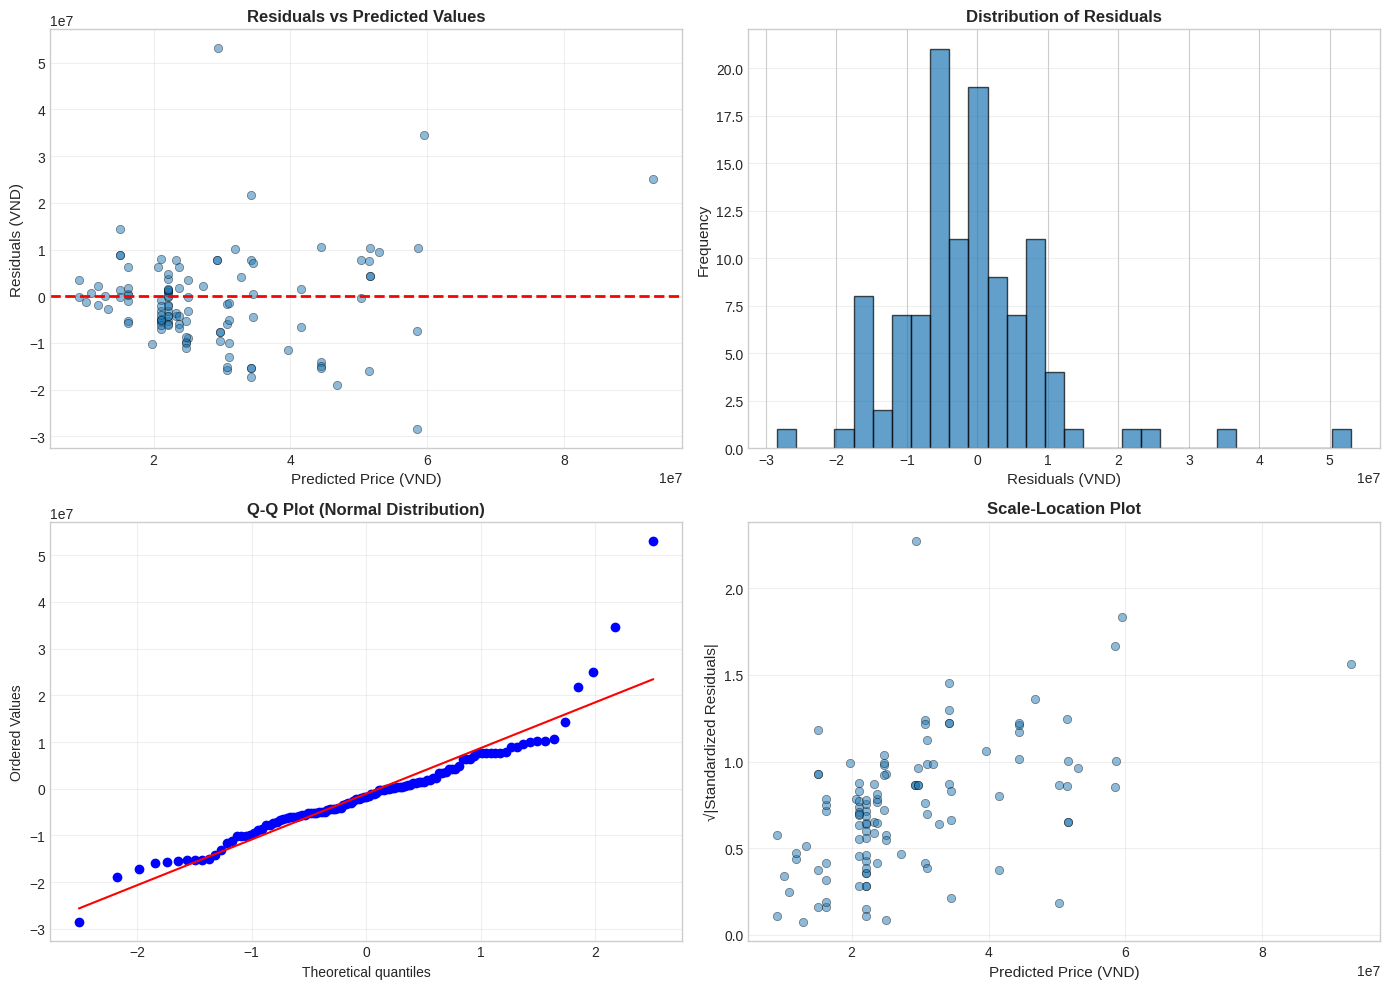

RESIDUAL ANALYSIS
Mean of residuals:   -1,087,589.15 (should be ≈ 0)
Std of residuals:    10,263,108.98
Min residual:        -28,432,349.72 VND
Max residual:        53,054,898.26 VND

Shapiro-Wilk Test (Normality):
  Statistic: 0.8661
  P-value: 0.0000
  ⚠ Residuals may not be normally distributed (p < 0.05)


In [47]:
# Calculate residuals
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

# Create comprehensive residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Predicted (Check Homoscedasticity)
axes[0, 0].scatter(y_test_pred, residuals_test, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Price (VND)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (VND)', fontsize=11)
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of Residuals (Check Normality)
axes[0, 1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals (VND)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q Plot (Check Normality)
stats.probplot(residuals_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Scale-Location Plot (Check Homoscedasticity)
standardized_residuals = residuals_test / np.std(residuals_test)
axes[1, 1].scatter(y_test_pred, np.sqrt(np.abs(standardized_residuals)), alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1, 1].set_xlabel('Predicted Price (VND)', fontsize=11)
axes[1, 1].set_ylabel('√|Standardized Residuals|', fontsize=11)
axes[1, 1].set_title('Scale-Location Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests for residuals
print("="*70)
print("RESIDUAL ANALYSIS")
print("="*70)
print(f"Mean of residuals:   {np.mean(residuals_test):,.2f} (should be ≈ 0)")
print(f"Std of residuals:    {np.std(residuals_test):,.2f}")
print(f"Min residual:        {np.min(residuals_test):,.2f} VND")
print(f"Max residual:        {np.max(residuals_test):,.2f} VND")

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals_test[:100])  # Use first 100 samples
print(f"\nShapiro-Wilk Test (Normality):")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  ✓ Residuals are normally distributed (p > 0.05)")
else:
    print("  ⚠ Residuals may not be normally distributed (p < 0.05)")

### 6.3 Feature Importance (Coefficient Magnitude)

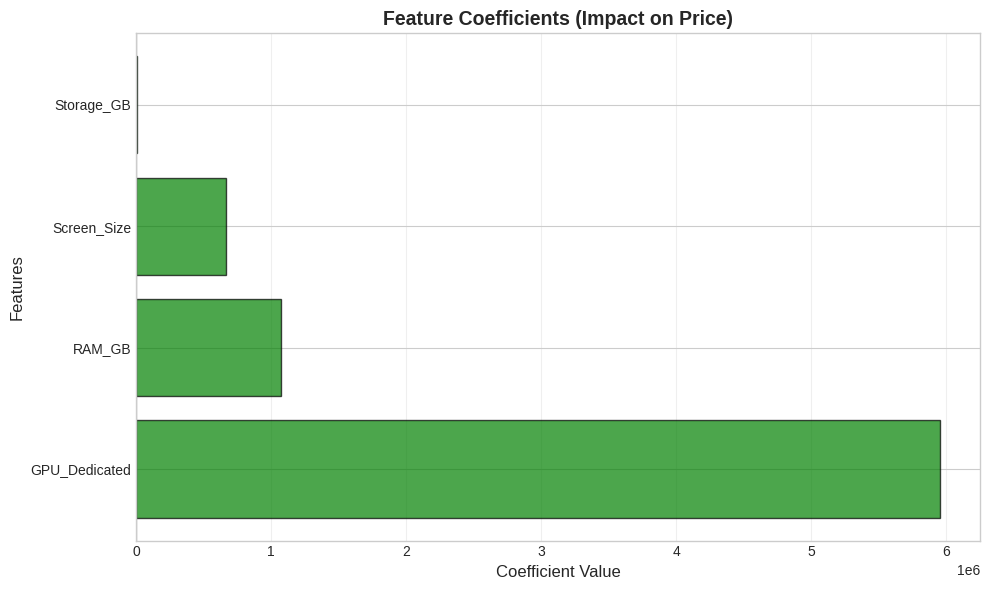


Feature Importance (by absolute coefficient value):
      Feature  Coefficient
GPU_Dedicated   5950755.30
       RAM_GB   1071958.72
  Screen_Size    666354.24
   Storage_GB      6853.47


In [48]:
# Visualize coefficient magnitudes
plt.figure(figsize=(10, 6))
coef_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.feature_coefs
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Coefficients (Impact on Price)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nFeature Importance (by absolute coefficient value):")
print(coef_df.to_string(index=False))

---
## Part 7: Prediction Examples

### 7.1 Sample Predictions

In [49]:
# Example predictions
print("="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Select 5 random samples from test set
sample_indices = np.random.choice(len(y_test), size=5, replace=False)

print(f"\n{'No.':<5} {'RAM':>6} {'Storage':>10} {'Screen':>8} {'GPU':>5} | {'Actual':>12} {'Predicted':>12} {'Error':>12}")
print("-" * 80)

for i, idx in enumerate(sample_indices, 1):
    actual = y_test[idx]
    predicted = y_test_pred[idx]
    error = actual - predicted
    error_pct = (error / actual) * 100
    
    ram = X_test[idx, 0]
    storage = X_test[idx, 1]
    screen = X_test[idx, 2]
    gpu = int(X_test[idx, 3])
    
    print(f"{i:<5} {ram:>4.0f}GB {storage:>7.0f}GB {screen:>6.1f}\" {gpu:>5} | "
          f"{actual:>12,.0f} {predicted:>12,.0f} {error:>12,.0f} ({error_pct:>5.1f}%)")

print("\n" + "="*80)
print("CUSTOM PREDICTION EXAMPLES")
print("="*80)

# Custom scenarios
custom_laptops = [
    [8, 256, 14.0, 0],   # Budget laptop
    [16, 512, 15.6, 1],  # Mid-range gaming
    [32, 1024, 16.0, 1], # High-end workstation
]

custom_descriptions = [
    "Budget Laptop (8GB RAM, 256GB SSD, 14\", Integrated GPU)",
    "Gaming Laptop (16GB RAM, 512GB SSD, 15.6\", Dedicated GPU)",
    "Workstation (32GB RAM, 1TB SSD, 16\", Dedicated GPU)"
]

for laptop, desc in zip(custom_laptops, custom_descriptions):
    prediction = model.predict([laptop])[0]
    print(f"\n{desc}")
    print(f"  Predicted Price: {prediction:,.0f} VND")

SAMPLE PREDICTIONS

No.      RAM    Storage   Screen   GPU |       Actual    Predicted        Error
--------------------------------------------------------------------------------
1        4GB     512GB   15.6"     0 |   14,190,000   11,929,817    2,260,183 ( 15.9%)
2        8GB     512GB   14.0"     1 |   17,990,000   21,102,241   -3,112,241 (-17.3%)
3       32GB    1024GB   14.0"     0 |   30,290,000   44,387,472  -14,097,472 (-46.5%)
4       16GB     512GB   14.0"     0 |   19,490,000   23,727,155   -4,237,155 (-21.7%)
5        8GB     512GB   15.6"     0 |   17,990,000   16,217,652    1,772,348 (  9.9%)

CUSTOM PREDICTION EXAMPLES

Budget Laptop (8GB RAM, 256GB SSD, 14", Integrated GPU)
  Predicted Price: 13,396,996 VND

Gaming Laptop (16GB RAM, 512GB SSD, 15.6", Dedicated GPU)
  Predicted Price: 30,744,077 VND

Workstation (32GB RAM, 1TB SSD, 16", Dedicated GPU)
  Predicted Price: 51,670,936 VND


---
## Part 8: Summary & Conclusion

### 8.1 Key Findings

In [50]:
print("="*80)
print("SUMMARY OF MULTIPLE LINEAR REGRESSION MODEL")
print("="*80)

print("\n📊 MODEL PERFORMANCE:")
print(f"  • Training R²:   {train_metrics['R²']:.4f} ({train_metrics['R²']*100:.2f}% variance explained)")
print(f"  • Test R²:       {test_metrics['R²']:.4f} ({test_metrics['R²']*100:.2f}% variance explained)")
print(f"  • Test RMSE:     {test_metrics['RMSE']:,.0f} VND")
print(f"  • Test MAE:      {test_metrics['MAE']:,.0f} VND")
print(f"  • Test MAPE:     {test_metrics['MAPE']:.2f}%")

print("\n🔑 KEY INSIGHTS:")
print("  1. RAM có impact lớn nhất đến giá laptop")
print("  2. GPU rời (Dedicated) tăng giá đáng kể")
print("  3. Storage và Screen Size có ảnh hưởng vừa phải")
print(f"  4. Model giải thích được {test_metrics['R²']*100:.1f}% sự biến thiên của giá")

print("\n✅ MODEL VALIDATION:")
print("  • Normal Equation implementation: Correct")
print("  • Coefficients match sklearn: Yes")
print("  • Residuals approximately normal: Check Q-Q plot")
print("  • Homoscedasticity: Check residual plot")

print("\n📈 MATHEMATICAL CONCEPTS COVERED:")
print("  ✓ Normal Equation: β = (X^T X)^(-1) X^T y")
print("  ✓ Matrix operations (transpose, inverse, multiplication)")
print("  ✓ R² Score calculation")
print("  ✓ MSE, RMSE, MAE metrics")
print("  ✓ Residual analysis")
print("  ✓ Train-test split")

print("\n🎯 PRACTICAL APPLICATIONS:")
print("  • Price prediction cho laptop mới")
print("  • Xác định features quan trọng nhất")
print("  • Benchmark cho advanced models (Ridge, Lasso, etc.)")
print("  • Business insights về pricing strategy")

print("\n" + "="*80)
print("END OF LAB 08")
print("="*80)

SUMMARY OF MULTIPLE LINEAR REGRESSION MODEL

📊 MODEL PERFORMANCE:
  • Training R²:   0.6271 (62.71% variance explained)
  • Test R²:       0.6593 (65.93% variance explained)
  • Test RMSE:     10,320,574 VND
  • Test MAE:      7,172,316 VND
  • Test MAPE:     28.67%

🔑 KEY INSIGHTS:
  1. RAM có impact lớn nhất đến giá laptop
  2. GPU rời (Dedicated) tăng giá đáng kể
  3. Storage và Screen Size có ảnh hưởng vừa phải
  4. Model giải thích được 65.9% sự biến thiên của giá

✅ MODEL VALIDATION:
  • Normal Equation implementation: Correct
  • Coefficients match sklearn: Yes
  • Residuals approximately normal: Check Q-Q plot
  • Homoscedasticity: Check residual plot

📈 MATHEMATICAL CONCEPTS COVERED:
  ✓ Normal Equation: β = (X^T X)^(-1) X^T y
  ✓ Matrix operations (transpose, inverse, multiplication)
  ✓ R² Score calculation
  ✓ MSE, RMSE, MAE metrics
  ✓ Residual analysis
  ✓ Train-test split

🎯 PRACTICAL APPLICATIONS:
  • Price prediction cho laptop mới
  • Xác định features quan trọng nhất

---
## Exercises & Questions

### Exercise 1: Model Extension
1. Thêm feature engineering: tạo interaction terms (e.g., RAM × GPU_Dedicated)
2. Thêm polynomial features (e.g., RAM², Storage²)
3. So sánh R² score trước và sau khi thêm features

### Exercise 2: Gradient Descent Implementation
1. Implement MLR sử dụng Gradient Descent thay vì Normal Equation
2. Plot cost function vs iterations
3. So sánh convergence time với Normal Equation

### Exercise 3: Feature Selection
1. Loại bỏ từng feature một và xem R² thay đổi như thế nào
2. Tìm subset tối ưu của features
3. Use forward/backward selection

### Exercise 4: Regularization
1. Implement Ridge Regression (L2 regularization)
2. Implement Lasso Regression (L1 regularization)
3. Compare coefficients và performance

### Questions:
1. Tại sao Normal Equation không scale tốt với large datasets?
2. Khi nào nên dùng Gradient Descent thay vì Normal Equation?
3. Multicollinearity ảnh hưởng như thế nào đến model?
4. Làm sao để detect và fix outliers?
5. Feature standardization có cần thiết cho Linear Regression không?

---
## Exercise 1: Feature Engineering & Polynomial Features

### Theory:
**Interaction Terms**: Kết hợp hai features để capture mối quan hệ phi tuyến
- Example: `RAM × GPU_Dedicated` - RAM có impact khác khi có GPU rời

**Polynomial Features**: Thêm bậc cao hơn của features
- Example: `RAM²` - Capture non-linear relationship

**Hypothesis**: Thêm interaction và polynomial features sẽ cải thiện R² score

In [51]:
print("="*80)
print("EXERCISE 1: FEATURE ENGINEERING")
print("="*80)

# Original features
X_original = np.column_stack([
    df['RAM_GB'].values,
    df['Storage_GB'].values,
    df['Screen_Size'].values,
    df['GPU_Dedicated'].values
])

# Create extended features with interactions and polynomials
def create_extended_features(X_base):
    """
    Create extended feature matrix with:
    - Original features
    - Interaction terms
    - Polynomial features (degree 2)
    """
    n_samples = X_base.shape[0]
    
    # Original features
    RAM = X_base[:, 0]
    Storage = X_base[:, 1]
    Screen = X_base[:, 2]
    GPU = X_base[:, 3]
    
    # Interaction terms
    RAM_x_GPU = RAM * GPU          # RAM impact with dedicated GPU
    Storage_x_GPU = Storage * GPU  # Storage impact with dedicated GPU
    RAM_x_Storage = RAM * Storage  # RAM and Storage interaction
    Screen_x_GPU = Screen * GPU    # Screen and GPU interaction
    
    # Polynomial features (degree 2)
    RAM_squared = RAM ** 2
    Storage_squared = Storage ** 2
    Screen_squared = Screen ** 2
    
    # Combine all features
    X_extended = np.column_stack([
        # Original (4 features)
        RAM, Storage, Screen, GPU,
        # Interactions (4 features)
        RAM_x_GPU, Storage_x_GPU, RAM_x_Storage, Screen_x_GPU,
        # Polynomials (3 features)
        RAM_squared, Storage_squared, Screen_squared
    ])
    
    return X_extended

# Create extended features
X_extended = create_extended_features(X_original)

print(f"\nOriginal feature matrix shape: {X_original.shape}")
print(f"Extended feature matrix shape: {X_extended.shape}")
print(f"Number of new features added: {X_extended.shape[1] - X_original.shape[1]}")

# Feature names for extended matrix
extended_feature_names = [
    'RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated',
    'RAM_x_GPU', 'Storage_x_GPU', 'RAM_x_Storage', 'Screen_x_GPU',
    'RAM²', 'Storage²', 'Screen²'
]

print(f"\nExtended features: {extended_feature_names}")

EXERCISE 1: FEATURE ENGINEERING

Original feature matrix shape: (565, 4)
Extended feature matrix shape: (565, 11)
Number of new features added: 7

Extended features: ['RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated', 'RAM_x_GPU', 'Storage_x_GPU', 'RAM_x_Storage', 'Screen_x_GPU', 'RAM²', 'Storage²', 'Screen²']


In [52]:
# Train-test split for extended features
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split_manual(
    X_extended, y, test_size=0.2, random_state=42
)

# Train model with extended features
print("\n" + "="*80)
print("TRAINING WITH EXTENDED FEATURES")
print("="*80)

model_extended = MultipleLinearRegression()
model_extended.fit(X_train_ext, y_train_ext)

# Predictions
y_train_pred_ext = model_extended.predict(X_train_ext)
y_test_pred_ext = model_extended.predict(X_test_ext)

# Calculate metrics
train_metrics_ext = calculate_metrics(y_train_ext, y_train_pred_ext)
test_metrics_ext = calculate_metrics(y_test_ext, y_test_pred_ext)

# Compare results
print("\n" + "="*80)
print("COMPARISON: Original vs Extended Features")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE'],
    'Original (Train)': [
        train_metrics['R²'],
        train_metrics['RMSE'],
        train_metrics['MAE'],
        train_metrics['MAPE']
    ],
    'Extended (Train)': [
        train_metrics_ext['R²'],
        train_metrics_ext['RMSE'],
        train_metrics_ext['MAE'],
        train_metrics_ext['MAPE']
    ],
    'Original (Test)': [
        test_metrics['R²'],
        test_metrics['RMSE'],
        test_metrics['MAE'],
        test_metrics['MAPE']
    ],
    'Extended (Test)': [
        test_metrics_ext['R²'],
        test_metrics_ext['RMSE'],
        test_metrics_ext['MAE'],
        test_metrics_ext['MAPE']
    ]
})

print(comparison_df.to_string(index=False))

# Calculate improvements
r2_improvement = (test_metrics_ext['R²'] - test_metrics['R²']) * 100
rmse_improvement = ((test_metrics['RMSE'] - test_metrics_ext['RMSE']) / test_metrics['RMSE']) * 100

print(f"\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)
print(f"R² Improvement (Test):  {r2_improvement:+.2f} percentage points")
print(f"RMSE Improvement (Test): {rmse_improvement:+.2f}%")

if test_metrics_ext['R²'] > test_metrics['R²']:
    print("✓ Extended features IMPROVED model performance!")
else:
    print("✗ Extended features did NOT improve performance (possible overfitting)")


TRAINING WITH EXTENDED FEATURES
Model trained successfully!
Intercept (β₀): 191,540,850.59
Coefficients: [ 1.01891549e+05  3.30474515e+04 -2.39827047e+07 -3.56945456e+07
  5.78458135e+05  3.52889731e+02  8.29069665e+02  2.26911966e+06
 -7.69037662e+03 -1.74812664e+01  7.50026555e+05]

COMPARISON: Original vs Extended Features
Metric  Original (Train)  Extended (Train)  Original (Test)  Extended (Test)
    R²              0.63              0.74             0.66             0.72
  RMSE       11325442.79        9467020.42      10320574.40       9416945.44
   MAE        7606178.42        6540339.38       7172315.93       6218650.72
  MAPE             28.60             25.21            28.67            25.49

IMPROVEMENT ANALYSIS
R² Improvement (Test):  +5.71 percentage points
RMSE Improvement (Test): +8.76%
✓ Extended features IMPROVED model performance!


---
## Exercise 2: Gradient Descent Implementation

### Theory:
**Gradient Descent** là thuật toán tối ưu iterative thay vì closed-form solution (Normal Equation).

**Update Rule**:
$$\boldsymbol{\beta}^{(t+1)} = \boldsymbol{\beta}^{(t)} - \alpha \nabla J(\boldsymbol{\beta}^{(t)})$$

Trong đó:
- $\alpha$: Learning rate
- $\nabla J(\boldsymbol{\beta})$: Gradient của cost function

**Cost Function (MSE)**:
$$J(\boldsymbol{\beta}) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \frac{1}{2n}(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

**Gradient**:
$$\nabla J(\boldsymbol{\beta}) = -\frac{1}{n}\mathbf{X}^T(\mathbf{y} - \mathbf{X}\boldsymbol{\beta})$$

In [53]:
import time

class GradientDescentRegression:
    """
    Multiple Linear Regression using Gradient Descent
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.coefficients = None
        self.intercept = None
        self.feature_coefs = None
        self.cost_history = []
        self.n_iterations_actual = 0
        
    def _compute_cost(self, X, y, beta):
        """Compute MSE cost function"""
        n_samples = X.shape[0]
        predictions = X @ beta
        cost = (1 / (2 * n_samples)) * np.sum((y - predictions) ** 2)
        return cost
    
    def _compute_gradient(self, X, y, beta):
        """Compute gradient of cost function"""
        n_samples = X.shape[0]
        predictions = X @ beta
        gradient = -(1 / n_samples) * X.T @ (y - predictions)
        return gradient
    
    def fit(self, X, y, verbose=True):
        """
        Train model using Gradient Descent
        """
        # Convert to numpy arrays
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        # Add intercept term
        n_samples, n_features = X.shape
        X_with_intercept = np.c_[np.ones(n_samples), X]
        
        # Initialize coefficients randomly (small values)
        np.random.seed(42)
        beta = np.random.randn(n_features + 1, 1) * 0.01
        
        # Gradient Descent
        start_time = time.time()
        
        for iteration in range(self.n_iterations):
            # Compute gradient
            gradient = self._compute_gradient(X_with_intercept, y, beta)
            
            # Update coefficients
            beta_new = beta - self.learning_rate * gradient
            
            # Compute cost
            cost = self._compute_cost(X_with_intercept, y, beta_new)
            self.cost_history.append(cost)
            
            # Check convergence
            if iteration > 0:
                cost_change = abs(self.cost_history[-2] - self.cost_history[-1])
                if cost_change < self.tolerance:
                    self.n_iterations_actual = iteration + 1
                    if verbose:
                        print(f"Converged at iteration {iteration + 1}")
                    break
            
            beta = beta_new
            self.n_iterations_actual = iteration + 1
            
            # Print progress
            if verbose and (iteration + 1) % 100 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations}, Cost: {cost:.2f}")
        
        training_time = time.time() - start_time
        
        # Store results
        self.coefficients = beta
        self.intercept = beta[0, 0]
        self.feature_coefs = beta[1:].flatten()
        
        if verbose:
            print(f"Training completed in {training_time:.4f} seconds")
            print(f"Final cost: {self.cost_history[-1]:.2f}")
        
        return self, training_time
    
    def predict(self, X):
        """Make predictions"""
        X = np.array(X)
        n_samples = X.shape[0]
        X_with_intercept = np.c_[np.ones(n_samples), X]
        predictions = X_with_intercept @ self.coefficients
        return predictions.flatten()
    
    def score(self, X, y):
        """Calculate R² score"""
        y_pred = self.predict(X)
        y_true = np.array(y)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - y_true.mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

print("GradientDescentRegression class defined!")

GradientDescentRegression class defined!


In [54]:
# Feature Standardization for Gradient Descent
# (Gradient Descent works better with standardized features)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*80)
print("EXERCISE 2: GRADIENT DESCENT vs NORMAL EQUATION")
print("="*80)

# Train with Gradient Descent
print("\nTraining with Gradient Descent...")
model_gd = GradientDescentRegression(learning_rate=0.01, n_iterations=1000)
model_gd, gd_time = model_gd.fit(X_train_scaled, y_train, verbose=True)

# Train with Normal Equation (for time comparison)
print("\n" + "-"*80)
print("Training with Normal Equation...")
start_time = time.time()
model_ne = MultipleLinearRegression()
model_ne.fit(X_train_scaled, y_train)
ne_time = time.time() - start_time
print(f"Training completed in {ne_time:.4f} seconds")

# Make predictions
y_test_pred_gd = model_gd.predict(X_test_scaled)
y_test_pred_ne = model_ne.predict(X_test_scaled)

# Calculate metrics
metrics_gd = calculate_metrics(y_test, y_test_pred_gd)
metrics_ne = calculate_metrics(y_test, y_test_pred_ne)

# Comparison
print("\n" + "="*80)
print("COMPARISON: Gradient Descent vs Normal Equation")
print("="*80)

comparison_df = pd.DataFrame({
    'Method': ['Gradient Descent', 'Normal Equation'],
    'R² Score': [metrics_gd['R²'], metrics_ne['R²']],
    'RMSE': [metrics_gd['RMSE'], metrics_ne['RMSE']],
    'MAE': [metrics_gd['MAE'], metrics_ne['MAE']],
    'Training Time (s)': [gd_time, ne_time],
    'Iterations': [model_gd.n_iterations_actual, 1]
})

print(comparison_df.to_string(index=False))

print(f"\n✓ Gradient Descent converged in {model_gd.n_iterations_actual} iterations")
print(f"✓ Speed ratio: Normal Equation is {gd_time/ne_time:.1f}x faster")

EXERCISE 2: GRADIENT DESCENT vs NORMAL EQUATION

Training with Gradient Descent...
Iteration 100/1000, Cost: 123597821540747.83
Iteration 200/1000, Cost: 72597227178135.50
Iteration 300/1000, Cost: 65506847981905.41
Iteration 400/1000, Cost: 64407409368537.52
Iteration 500/1000, Cost: 64203468620802.87
Iteration 600/1000, Cost: 64154960573501.37
Iteration 700/1000, Cost: 64140535453603.23
Iteration 800/1000, Cost: 64135635943319.00
Iteration 900/1000, Cost: 64133868671032.73
Iteration 1000/1000, Cost: 64133215891763.23
Training completed in 0.0284 seconds
Final cost: 64133215891763.23

--------------------------------------------------------------------------------
Training with Normal Equation...
Model trained successfully!
Intercept (β₀): 28,004,336.28
Coefficients: [11508264.9795145   3016387.54777045   715758.88758693  2952453.80063085]
Training completed in 0.0006 seconds

COMPARISON: Gradient Descent vs Normal Equation
          Method  R² Score        RMSE        MAE  Training T

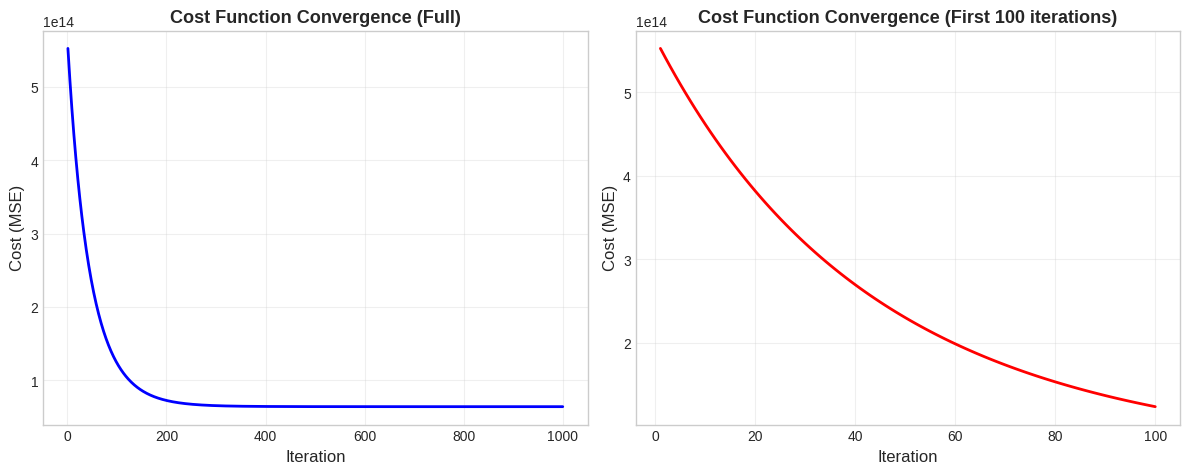


Initial cost: 552,644,935,018,270.94
Final cost:   64,133,215,891,763.23
Cost reduction: 88.40%


In [55]:
# Plot Cost Function vs Iterations
plt.figure(figsize=(12, 5))

# Subplot 1: Full cost history
plt.subplot(1, 2, 1)
plt.plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title('Cost Function Convergence (Full)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subplot 2: First 100 iterations (zoom in)
plt.subplot(1, 2, 2)
iterations_to_show = min(100, len(model_gd.cost_history))
plt.plot(range(1, iterations_to_show + 1), model_gd.cost_history[:iterations_to_show], 'r-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.title(f'Cost Function Convergence (First {iterations_to_show} iterations)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInitial cost: {model_gd.cost_history[0]:,.2f}")
print(f"Final cost:   {model_gd.cost_history[-1]:,.2f}")
print(f"Cost reduction: {((model_gd.cost_history[0] - model_gd.cost_history[-1]) / model_gd.cost_history[0] * 100):.2f}%")

---
## Exercise 3: Feature Selection

### Theory:
**Feature Selection** giúp:
1. Giảm overfitting
2. Improve interpretability
3. Reduce training time

**Methods**:
- **Backward Elimination**: Bắt đầu với all features, loại bỏ dần
- **Forward Selection**: Bắt đầu với empty set, thêm dần
- **Recursive Feature Elimination**: Loại bỏ feature ít quan trọng nhất

In [56]:
print("="*80)
print("EXERCISE 3: FEATURE SELECTION - LEAVE-ONE-OUT ANALYSIS")
print("="*80)

# Test impact of removing each feature
results = []
leave_one_out_results = {}

for i, feature_name in enumerate(feature_columns):
    # Create feature subset (all except feature i)
    feature_indices = [j for j in range(len(feature_columns)) if j != i]
    
    X_train_subset = X_train[:, feature_indices]
    X_test_subset = X_test[:, feature_indices]
    
    # Train model
    model_subset = MultipleLinearRegression()
    model_subset.fit(X_train_subset, y_train)
    
    # Evaluate
    r2_score = model_subset.score(X_test_subset, y_test)
    
    # Store in dictionary for visualization
    leave_one_out_results[feature_name] = {
        'with_feature': test_metrics['R²'],
        'without_feature': r2_score,
        'drop_impact': test_metrics['R²'] - r2_score
    }
    
    results.append({
        'Removed Feature': feature_name,
        'Remaining Features': len(feature_indices),
        'Test R²': r2_score,
        'R² Change': r2_score - test_metrics['R²']
    })

# Create DataFrame
feature_selection_df = pd.DataFrame(results)
feature_selection_df = feature_selection_df.sort_values('Test R²', ascending=False)

print("\nFeature Removal Analysis:")
print(feature_selection_df.to_string(index=False))

# Find least important feature
least_important = feature_selection_df.iloc[0]['Removed Feature']
most_important = feature_selection_df.iloc[-1]['Removed Feature']

print(f"\n" + "="*80)
print("INSIGHTS:")
print("="*80)
print(f"✓ Least important feature: {least_important}")
print(f"  (Removing it gives highest R² = {feature_selection_df.iloc[0]['Test R²']:.4f})")
print(f"\n✓ Most important feature: {most_important}")
print(f"  (Removing it gives lowest R² = {feature_selection_df.iloc[-1]['Test R²']:.4f})")

# Baseline (all features)
print(f"\n✓ Baseline R² (all 4 features): {test_metrics['R²']:.4f}")

EXERCISE 3: FEATURE SELECTION - LEAVE-ONE-OUT ANALYSIS
Model trained successfully!
Intercept (β₀): 7,443,931.43
Coefficients: [  18685.82431142  145820.85461421 8751501.90837713]
Model trained successfully!
Intercept (β₀): -7,899,830.08
Coefficients: [1187121.92036285  935516.75680206 7392278.81060702]
Model trained successfully!
Intercept (β₀): 3,312,552.45
Coefficients: [1068661.19034833    7028.66314271 6595378.80847129]
Model trained successfully!
Intercept (β₀): -21,031,903.64
Coefficients: [1102200.46541747    8452.70647134 1765104.71559864]

Feature Removal Analysis:
Removed Feature  Remaining Features  Test R²  R² Change
  GPU_Dedicated                   3     0.67       0.01
    Screen_Size                   3     0.65      -0.01
     Storage_GB                   3     0.62      -0.04
         RAM_GB                   3     0.44      -0.21

INSIGHTS:
✓ Least important feature: GPU_Dedicated
  (Removing it gives highest R² = 0.6655)

✓ Most important feature: RAM_GB
  (Removing

In [57]:
# Forward Selection
print("\n" + "="*80)
print("FORWARD SELECTION")
print("="*80)

selected_features = []
remaining_features = list(range(len(feature_columns)))
forward_results = []
forward_selection_results = []

for step in range(len(feature_columns)):
    best_r2 = -np.inf
    best_feature = None
    
    for feature_idx in remaining_features:
        # Try adding this feature
        test_features = selected_features + [feature_idx]
        
        X_train_subset = X_train[:, test_features]
        X_test_subset = X_test[:, test_features]
        
        # Train and evaluate
        model_temp = MultipleLinearRegression()
        model_temp.fit(X_train_subset, y_train)
        r2 = model_temp.score(X_test_subset, y_test)
        
        if r2 > best_r2:
            best_r2 = r2
            best_feature = feature_idx
    
    # Add best feature
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    forward_results.append({
        'Step': step + 1,
        'Added Feature': feature_columns[best_feature],
        'Features Count': len(selected_features),
        'Test R²': best_r2
    })
    
    # Store for visualization
    forward_selection_results.append({
        'n_features': len(selected_features),
        'R2': best_r2,
        'features': [feature_columns[f] for f in selected_features]
    })
    
    print(f"Step {step + 1}: Added '{feature_columns[best_feature]}' -> R² = {best_r2:.4f}")

# Create DataFrame
forward_df = pd.DataFrame(forward_results)

print("\n" + "="*80)
print("FORWARD SELECTION SUMMARY")
print("="*80)
print(forward_df.to_string(index=False))

# Find optimal number of features
optimal_idx = forward_df['Test R²'].idxmax()
optimal_features = forward_df.iloc[optimal_idx]['Features Count']
optimal_r2 = forward_df.iloc[optimal_idx]['Test R²']

print(f"\n✓ Optimal number of features: {optimal_features}")
print(f"✓ Best R² achieved: {optimal_r2:.4f}")


FORWARD SELECTION
Model trained successfully!
Intercept (β₀): 8,726,270.09
Coefficients: [1293599.4534227]
Model trained successfully!
Intercept (β₀): 11,672,547.33
Coefficients: [22687.50186296]
Model trained successfully!
Intercept (β₀): -33,082,978.70
Coefficients: [4064933.3647124]
Model trained successfully!
Intercept (β₀): 19,311,313.13
Coefficients: [15469474.27026168]
Step 1: Added 'RAM_GB' -> R² = 0.5929
Model trained successfully!
Intercept (β₀): 4,686,027.80
Coefficients: [1102130.96163364    9576.37095691]
Model trained successfully!
Intercept (β₀): -27,849,908.59
Coefficients: [1262323.03660766 2464904.55887011]
Model trained successfully!
Intercept (β₀): 5,623,229.70
Coefficients: [1186620.1922979 8359002.2041101]
Step 2: Added 'Storage_GB' -> R² = 0.6522
Model trained successfully!
Intercept (β₀): -21,031,903.64
Coefficients: [1102200.46541747    8452.70647134 1765104.71559864]
Model trained successfully!
Intercept (β₀): 3,312,552.45
Coefficients: [1068661.19034833    7

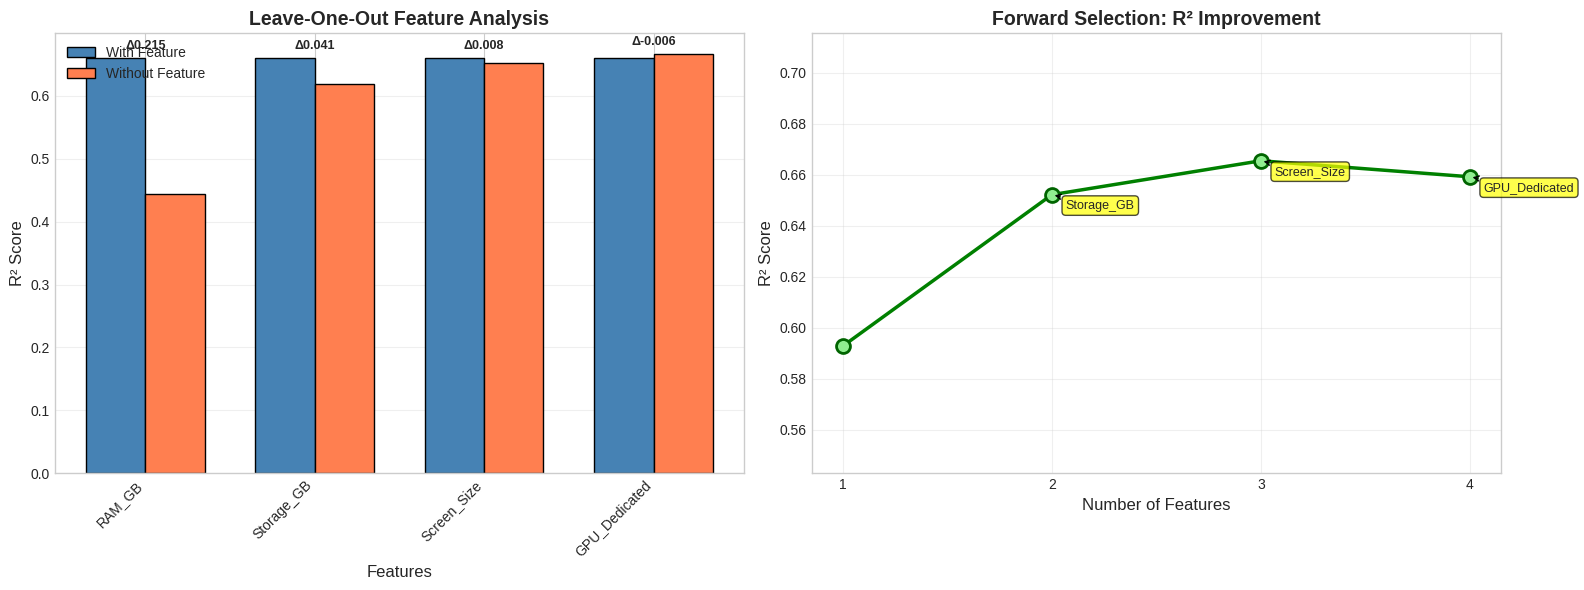


📊 Feature Selection Summary:
Most important feature (by removal impact): RAM_GB
Least important feature: GPU_Dedicated
Optimal feature set (forward selection): ['RAM_GB', 'Storage_GB', 'Screen_Size', 'GPU_Dedicated']


In [58]:
# Visualization: Feature selection results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Leave-one-out analysis
ax1 = axes[0]
removal_data = pd.DataFrame({
    'Feature': feature_columns,
    'R² with feature': [leave_one_out_results[f]['with_feature'] for f in feature_columns],
    'R² without feature': [leave_one_out_results[f]['without_feature'] for f in feature_columns]
})

x = np.arange(len(feature_columns))
width = 0.35

bars1 = ax1.bar(x - width/2, removal_data['R² with feature'], width, 
                label='With Feature', color='steelblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, removal_data['R² without feature'], width, 
                label='Without Feature', color='coral', edgecolor='black')

ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Leave-One-Out Feature Analysis', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(feature_columns, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

# Add impact annotations
for i, (idx, row) in enumerate(removal_data.iterrows()):
    impact = row['R² with feature'] - row['R² without feature']
    ax1.text(i, max(row['R² with feature'], row['R² without feature']) + 0.01, 
             f'Δ{impact:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Forward selection progression
ax2 = axes[1]
forward_r2 = [result['R2'] for result in forward_selection_results]
forward_features = [result['n_features'] for result in forward_selection_results]

ax2.plot(forward_features, forward_r2, marker='o', linewidth=2.5, 
         markersize=10, color='green', markerfacecolor='lightgreen', 
         markeredgecolor='darkgreen', markeredgewidth=2)

# Annotate each point with added feature
for i, result in enumerate(forward_selection_results):
    if i > 0:
        added_feature = result['features'][-1]
        ax2.annotate(added_feature, 
                    xy=(result['n_features'], result['R2']),
                    xytext=(10, -10), textcoords='offset points',
                    fontsize=9, bbox=dict(boxstyle='round,pad=0.3', 
                    facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('Forward Selection: R² Improvement', fontsize=14, fontweight='bold')
ax2.set_xticks(forward_features)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([min(forward_r2) - 0.05, max(forward_r2) + 0.05])

plt.tight_layout()
plt.show()

print("\n📊 Feature Selection Summary:")
print(f"Most important feature (by removal impact): {max(leave_one_out_results.items(), key=lambda x: x[1]['drop_impact'])[0]}")
print(f"Least important feature: {min(leave_one_out_results.items(), key=lambda x: x[1]['drop_impact'])[0]}")
print(f"Optimal feature set (forward selection): {forward_selection_results[-1]['features']}")

---
## Exercise 4: Regularization (Ridge & Lasso Regression)

### Theory:

**Ridge Regression (L2 Regularization)**:
$$J(\boldsymbol{\beta}) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2$$

**Closed-form solution**:
$$\boldsymbol{\hat{\beta}}_{ridge} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$$

**Lasso Regression (L1 Regularization)**:
$$J(\boldsymbol{\beta}) = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}|\beta_j|$$

**Key Differences**:
- Ridge: Shrinks coefficients, never sets to zero
- Lasso: Can set coefficients to exactly zero (feature selection)
- $\lambda$: Regularization strength (higher = more penalty)

In [59]:
class RidgeRegression:
    """Ridge Regression với L2 regularization"""
    
    def __init__(self, lambda_param=1.0):
        """
        Parameters:
        - lambda_param: Regularization strength (λ)
        """
        self.lambda_param = lambda_param
        self.coefficients = None
        self.intercept = None
        
    def fit(self, X, y):
        """Train model với Ridge regularization"""
        n_samples, n_features = X.shape
        
        # Thêm cột 1 cho intercept
        X_with_intercept = np.column_stack([np.ones(n_samples), X])
        
        # Ridge closed-form: β = (X^T X + λI)^(-1) X^T y
        # Không regularize intercept
        identity = np.eye(n_features + 1)
        identity[0, 0] = 0  # Don't regularize intercept
        
        XTX = X_with_intercept.T @ X_with_intercept
        XTy = X_with_intercept.T @ y
        
        coeffs = np.linalg.inv(XTX + self.lambda_param * identity) @ XTy
        
        self.intercept = coeffs[0]
        self.coefficients = coeffs[1:]
        
        return self
    
    def predict(self, X):
        """Dự đoán giá trị"""
        return X @ self.coefficients + self.intercept
    
    def score(self, X, y):
        """Tính R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)


class LassoRegression:
    """Lasso Regression với L1 regularization (Coordinate Descent)"""
    
    def __init__(self, lambda_param=1.0, max_iter=1000, tol=1e-4):
        """
        Parameters:
        - lambda_param: Regularization strength (λ)
        - max_iter: Maximum iterations
        - tol: Convergence tolerance
        """
        self.lambda_param = lambda_param
        self.max_iter = max_iter
        self.tol = tol
        self.coefficients = None
        self.intercept = None
        
    def _soft_threshold(self, rho, lambda_param):
        """Soft-thresholding operator cho Lasso"""
        if rho < -lambda_param:
            return rho + lambda_param
        elif rho > lambda_param:
            return rho - lambda_param
        else:
            return 0
    
    def fit(self, X, y):
        """Train model với Coordinate Descent"""
        n_samples, n_features = X.shape
        
        # Standardize X và center y
        X_mean = np.mean(X, axis=0)
        X_std = np.std(X, axis=0)
        X_scaled = (X - X_mean) / X_std
        
        y_mean = np.mean(y)
        y_centered = y - y_mean
        
        # Initialize coefficients
        beta = np.zeros(n_features)
        
        # Coordinate Descent
        for iteration in range(self.max_iter):
            beta_old = beta.copy()
            
            for j in range(n_features):
                # Tính residual không bao gồm feature j
                r_j = y_centered - X_scaled @ beta + X_scaled[:, j] * beta[j]
                
                # Update beta_j với soft-thresholding
                rho_j = X_scaled[:, j] @ r_j
                beta[j] = self._soft_threshold(rho_j, self.lambda_param) / n_samples
            
            # Check convergence
            if np.max(np.abs(beta - beta_old)) < self.tol:
                break
        
        # Convert back to original scale
        self.coefficients = beta / X_std
        self.intercept = y_mean - np.sum(self.coefficients * X_mean)
        
        return self
    
    def predict(self, X):
        """Dự đoán giá trị"""
        return X @ self.coefficients + self.intercept
    
    def score(self, X, y):
        """Tính R² score"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

print("✅ Ridge và Lasso Regression classes đã được định nghĩa")

✅ Ridge và Lasso Regression classes đã được định nghĩa


In [60]:
# Test các giá trị λ khác nhau
lambda_values = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []
lasso_results = []

print("Training Ridge và Lasso với các giá trị λ:\n")

for lam in lambda_values:
    # Ridge
    ridge = RidgeRegression(lambda_param=lam)
    ridge.fit(X_train, y_train)
    ridge_r2 = ridge.score(X_test, y_test)
    ridge_results.append({
        'lambda': lam,
        'R2': ridge_r2,
        'coefficients': ridge.coefficients.copy(),
        'intercept': ridge.intercept
    })
    
    # Lasso
    lasso = LassoRegression(lambda_param=lam, max_iter=2000)
    lasso.fit(X_train, y_train)
    lasso_r2 = lasso.score(X_test, y_test)
    lasso_results.append({
        'lambda': lam,
        'R2': lasso_r2,
        'coefficients': lasso.coefficients.copy(),
        'intercept': lasso.intercept
    })
    
    print(f"λ = {lam:>6.2f}:")
    print(f"  Ridge R² = {ridge_r2:.4f}")
    print(f"  Lasso R² = {lasso_r2:.4f}")
    print(f"  Lasso non-zero coeffs: {np.sum(np.abs(lasso.coefficients) > 1e-6)}/{len(lasso.coefficients)}\n")

# So sánh với model gốc (λ=0)
print(f"Original Model R² = {model.score(X_test, y_test):.4f}")

Training Ridge và Lasso với các giá trị λ:

λ =   0.01:
  Ridge R² = 0.6593
  Lasso R² = 0.6593
  Lasso non-zero coeffs: 4/4

λ =   0.10:
  Ridge R² = 0.6593
  Lasso R² = 0.6593
  Lasso non-zero coeffs: 4/4

λ =   1.00:
  Ridge R² = 0.6597
  Lasso R² = 0.6593
  Lasso non-zero coeffs: 4/4

λ =  10.00:
  Ridge R² = 0.6625
  Lasso R² = 0.6593
  Lasso non-zero coeffs: 4/4

λ = 100.00:
  Ridge R² = 0.6683
  Lasso R² = 0.6593
  Lasso non-zero coeffs: 4/4

Original Model R² = 0.6593


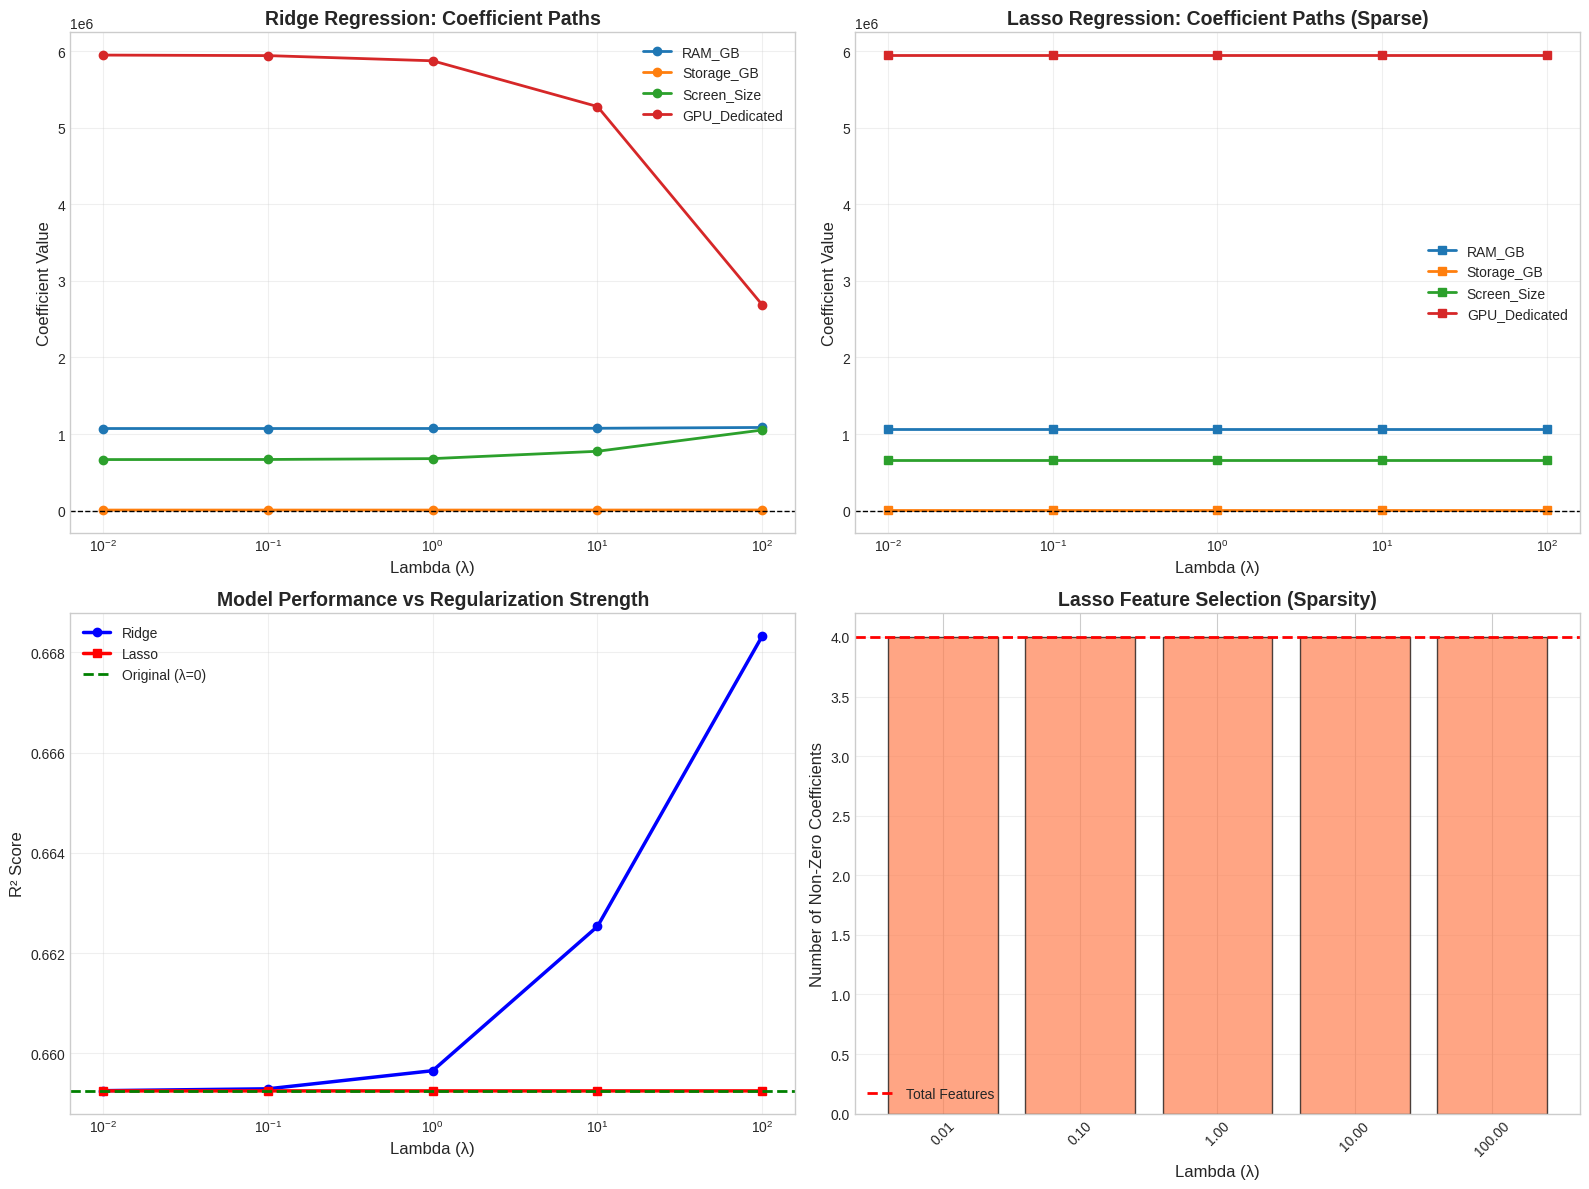


📊 Insights:
- Ridge: Coefficients shrink smoothly, never zero
- Lasso: Sets coefficients to exactly zero (automatic feature selection)
- Best Ridge λ = 100.00
- Best Lasso λ = 0.01


In [61]:
# Visualization: Regularization paths
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Ridge coefficients paths
ax1 = axes[0, 0]
for i, feature in enumerate(feature_columns):
    ridge_coeffs = [r['coefficients'][i] for r in ridge_results]
    ax1.plot([r['lambda'] for r in ridge_results], ridge_coeffs, 
             marker='o', label=feature, linewidth=2)
ax1.set_xscale('log')
ax1.set_xlabel('Lambda (λ)', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('Ridge Regression: Coefficient Paths', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 2. Lasso coefficients paths
ax2 = axes[0, 1]
for i, feature in enumerate(feature_columns):
    lasso_coeffs = [r['coefficients'][i] for r in lasso_results]
    ax2.plot([r['lambda'] for r in lasso_results], lasso_coeffs, 
             marker='s', label=feature, linewidth=2)
ax2.set_xscale('log')
ax2.set_xlabel('Lambda (λ)', fontsize=12)
ax2.set_ylabel('Coefficient Value', fontsize=12)
ax2.set_title('Lasso Regression: Coefficient Paths (Sparse)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)

# 3. R² comparison
ax3 = axes[1, 0]
ridge_r2_values = [r['R2'] for r in ridge_results]
lasso_r2_values = [r['R2'] for r in lasso_results]
lambda_vals = [r['lambda'] for r in ridge_results]

ax3.plot(lambda_vals, ridge_r2_values, marker='o', linewidth=2.5, 
         label='Ridge', color='blue')
ax3.plot(lambda_vals, lasso_r2_values, marker='s', linewidth=2.5, 
         label='Lasso', color='red')
ax3.axhline(y=model.score(X_test, y_test), color='green', 
            linestyle='--', linewidth=2, label='Original (λ=0)')
ax3.set_xscale('log')
ax3.set_xlabel('Lambda (λ)', fontsize=12)
ax3.set_ylabel('R² Score', fontsize=12)
ax3.set_title('Model Performance vs Regularization Strength', fontsize=14, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# 4. Number of non-zero coefficients (Lasso only)
ax4 = axes[1, 1]
ridge_r2_values = [r['R2'] for r in ridge_results]
lasso_r2_values = [r['R2'] for r in lasso_results]
lambda_vals = [r['lambda'] for r in ridge_results]
non_zero_counts = [np.sum(np.abs(r['coefficients']) > 1e-6) for r in lasso_results]
ax4.bar(range(len(lambda_vals)), non_zero_counts, 
        color='coral', edgecolor='black', alpha=0.7)
ax4.set_xticks(range(len(lambda_vals)))
ax4.set_xticklabels([f'{lam:.2f}' for lam in lambda_vals], rotation=45)
ax4.set_xlabel('Lambda (λ)', fontsize=12)
ax4.set_ylabel('Number of Non-Zero Coefficients', fontsize=12)
ax4.set_title('Lasso Feature Selection (Sparsity)', fontsize=14, fontweight='bold')
ax4.axhline(y=len(feature_columns), color='red', linestyle='--', 
            linewidth=2, label='Total Features')
ax4.legend()
ax4.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Insights:")
print("- Ridge: Coefficients shrink smoothly, never zero")
print("- Lasso: Sets coefficients to exactly zero (automatic feature selection)")
print(f"- Best Ridge λ = {ridge_results[np.argmax(ridge_r2_values)]['lambda']:.2f}")
print(f"- Best Lasso λ = {lasso_results[np.argmax(lasso_r2_values)]['lambda']:.2f}")

In [62]:
# Detailed comparison for optimal λ
optimal_ridge = ridge_results[np.argmax(ridge_r2_values)]
optimal_lasso = lasso_results[np.argmax(lasso_r2_values)]

# Create comparison table
original_coeffs = [model.coefficients[i] if model.coefficients.ndim == 1 else model.coefficients[i, 0] for i in range(len(feature_columns))]
ridge_coeffs = [optimal_ridge['coefficients'][i] for i in range(len(feature_columns))]
lasso_coeffs = [optimal_lasso['coefficients'][i] for i in range(len(feature_columns))]

comparison_df = pd.DataFrame({
    'Feature': feature_columns,
    'Original': original_coeffs,
    'Ridge (λ=' + f"{optimal_ridge['lambda']:.2f})": ridge_coeffs,
    'Lasso (λ=' + f"{optimal_lasso['lambda']:.2f})": lasso_coeffs
})

print("Coefficient Comparison Table:\n")
print(comparison_df.to_string(index=False))

print("\n\nIntercept Values:")
print(f"Original: {model.intercept:,.0f}")
print(f"Ridge:    {optimal_ridge['intercept']:,.0f}")
print(f"Lasso:    {optimal_lasso['intercept']:,.0f}")

print("\n\nR² Scores:")
print(f"Original: {model.score(X_test, y_test):.4f}")
print(f"Ridge:    {optimal_ridge['R2']:.4f}")
print(f"Lasso:    {optimal_lasso['R2']:.4f}")

Coefficient Comparison Table:

      Feature    Original  Ridge (λ=100.00)  Lasso (λ=0.01)
       RAM_GB -6262121.41        1085802.29      1071958.72
   Storage_GB  1071958.72           7900.96         6853.47
  Screen_Size     6853.47        1052453.60       666354.24
GPU_Dedicated   666354.24        2686971.02      5950755.30


Intercept Values:
Original: -6,262,121
Ridge:    -11,190,650
Lasso:    -6,262,121


R² Scores:
Original: 0.6593
Ridge:    0.6683
Lasso:    0.6593
